In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Step 1 : Install Required Libraries

In [ ]:
pip install numpy pandas scikit-learn opencv-python matplotlib

Step 2 : Load Required Libraries

In [ ]:

import pandas as pd
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt
import os


Explanation:

NumPy: For numerical operations and handling arrays.
Pandas: For data manipulation and analysis.
OpenCV: For image processing tasks.
Scikit-learn: For implementing machine learning models and metrics.
Matplotlib: For visualizing results.


Step 3 : Load the Cohen-Candy Dataset

In [ ]:
import pandas as pd

csv_path = '/content/drive/MyDrive/MS THESIS_CSE_EWU/ckextended.csv'
data = pd.read_csv(csv_path)
print(data.columns)  # This will show the column names



Index(['emotion', 'pixels', 'Usage'], dtype='object')


you have the column names from your CSV file (emotion, pixels, and Usage), you can adjust your load_dataset function accordingly.

Adjusting the load_dataset Function
Based on the columns you have:

emotion: This is likely the label for the facial expression.
pixels: This should contain the pixel values for each image, probably in string format (like a flattened array).
Usage: This might indicate whether the data is for training, validation, or testing.
You will need to modify the load_dataset function to read the pixel values and convert them into images. Here’s how to do that:

In [ ]:
import pandas as pd
import numpy as np
import cv2

def load_dataset(csv_path):
    images = []
    labels = []

    # Load the CSV file
    data = pd.read_csv(csv_path)

    for index, row in data.iterrows():
        # Convert pixel values into an array
        pixel_array = np.fromstring(row['pixels'], sep=' ')  # Assuming pixels are space-separated
        image = pixel_array.reshape(48, 48).astype(np.uint8)  # Reshape to 48x48 and convert to uint8

        label = row['emotion']  # Get the label

        images.append(image)
        labels.append(label)

    return np.array(images), np.array(labels)

# Update with the correct path to your CSV file
csv_path = '/content/drive/MyDrive/MS THESIS_CSE_EWU/ckextended.csv'
images, labels = load_dataset(csv_path)


Explanation of Changes:
Converting Pixel Values:
np.fromstring(row['pixels'], sep=' '): This converts the string of pixel values into a NumPy array, using space as the delimiter.
image.reshape(48, 48): Reshape the flat array into a 48x48 image.
.astype(np.uint8): Convert the pixel values to unsigned 8-bit integers, which is the standard format for grayscale images.
Collecting Labels:
The label is taken directly from the emotion column.
After Making Changes
Run the Updated Code: Execute the updated script to load your images and labels.
Check for Image Shape: If you want to verify that images are loaded correctly, you can print the shape of the first image and the corresponding label:

In [ ]:
print(f"First image shape: {images[0].shape}, Label: {labels[0]}")


First image shape: (48, 48), Label: 6


Step 4 : Preprocess the Images

In [ ]:
def preprocess_images(images):
    processed_images = []
    for img in images:
        # Assuming img is already a grayscale image of shape (48, 48)
        resized = cv2.resize(img, (48, 48))  # Resize if necessary
        processed_images.append(resized.flatten())  # Flatten the image into a vector

    return np.array(processed_images)


In [ ]:
print(f"Original image shape: {images[0].shape}")
processed_images = preprocess_images(images)
print(f"Processed image shape: {processed_images[0].shape}")


Original image shape: (48, 48)
Processed image shape: (2304,)


Explanation of the Flattening Process
Flattening: When you flatten a

48×48 image, you convert it into a single vector with

48×48=2304 elements. This is common when preparing image data for machine learning models that require input as one-dimensional arrays.




Step 5 : Feature Extraction Using Cosine Similarity



In [ ]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def adjust_radius(features, variance_threshold=0.1):
    variance = np.var(features, axis=0)
    dynamic_radius = np.where(variance > variance_threshold, 1.5, 1.0)  # Adjust based on variance
    return dynamic_radius

def extract_features(images):
    features = []
    radius = adjust_radius(images)
    for img in images:
        # For demonstration, using raw pixel values as features
        feature_vector = img  # Replace this with a more sophisticated feature extraction method if needed
        features.append(feature_vector)
    return np.array(features)

features = extract_features(processed_images)


Explanation:

Cosine Similarity: Measures the similarity between two vectors. This can be useful in determining how alike different facial expression features are.
Dynamic Radius Adjustment: Sets a radius based on the variance in features, helping to tune the sensitivity of the model to variations in expression.
Feature Extraction: In this example, raw pixel values are used. However, consider more advanced feature extraction techniques like Local Binary Patterns (LBP) for better performance.

Step 6: Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)


Explanation:

Train-Test Split: This divides your dataset so that 80% of the data is used for training the model, and 20% is used for testing its performance.


Step 7: Train Multiple Models

In [ ]:
models = {
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Logistic Regression': LogisticRegression(max_iter=200),
    'Gradient Boosting': GradientBoostingClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)  # Train the model
    y_pred = model.predict(X_test)  # Predict on the test set
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted'),
        'recall': recall_score(y_test, y_pred, average='weighted'),
        'f1_score': f1_score(y_test, y_pred, average='weighted')
    }


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

Explanation:

Model Training: Each algorithm is trained on the training set.
Evaluation Metrics:
Accuracy: Overall correctness of the model.
Precision: Proportion of true positive results in all positive predictions.
Recall: Proportion of true positives identified out of actual positives.
F1 Score: Harmonic mean of precision and recall, providing a balance between the two.


Step 8: Evaluate Results

In [ ]:
for name, metrics in results.items():
    print(f"{name}: {metrics}")


KNN: {'accuracy': 0.657608695652174, 'precision': 0.542572463768116, 'recall': 0.657608695652174, 'f1_score': 0.5488142292490119}
SVM: {'accuracy': 0.782608695652174, 'precision': 0.7072096862960925, 'recall': 0.782608695652174, 'f1_score': 0.7043308155020043}
Decision Tree: {'accuracy': 0.6956521739130435, 'precision': 0.6936373831977004, 'recall': 0.6956521739130435, 'f1_score': 0.6926828505504282}
Random Forest: {'accuracy': 0.7934782608695652, 'precision': 0.71335005574136, 'recall': 0.7934782608695652, 'f1_score': 0.7247275181313977}
Logistic Regression: {'accuracy': 0.8586956521739131, 'precision': 0.8205380717680488, 'recall': 0.8586956521739131, 'f1_score': 0.8304621241157006}
Gradient Boosting: {'accuracy': 0.8043478260869565, 'precision': 0.7572101449275361, 'recall': 0.8043478260869565, 'f1_score': 0.7604226835245654}


Explanation:

This loop displays the performance of each model based on the previously calculated metrics, allowing you to compare their effectiveness directly.


Model Performance Summary
From my results:

KNN:
Accuracy: 65.76%
Precision: 54.26%
Recall: 65.76%
F1 Score: 54.88%
SVM:
Accuracy: 78.26%
Precision: 70.72%
Recall: 78.26%
F1 Score: 70.43%
Decision Tree:
Accuracy: 69.57%
Precision: 69.36%
Recall: 69.57%
F1 Score: 69.27%
Random Forest:
Accuracy: 79.35%
Precision: 71.34%
Recall: 79.35%
F1 Score: 72.47%
Logistic Regression:
Accuracy: 85.87%
Precision: 82.05%
Recall: 85.87%
F1 Score: 83.05%
Gradient Boosting:
Accuracy: 80.43%
Precision: 75.72%
Recall: 80.43%
F1 Score: 76.04%
Optimal Model
Based on these metrics, Logistic Regression appears to be the best-performing model overall:

Highest Accuracy: 85.87%
High Precision and Recall: This indicates that it not only has a high true positive rate but also makes fewer false positive predictions.
Best F1 Score: 83.05%, which balances precision and recall effectively.

Step 9: Visualize Results

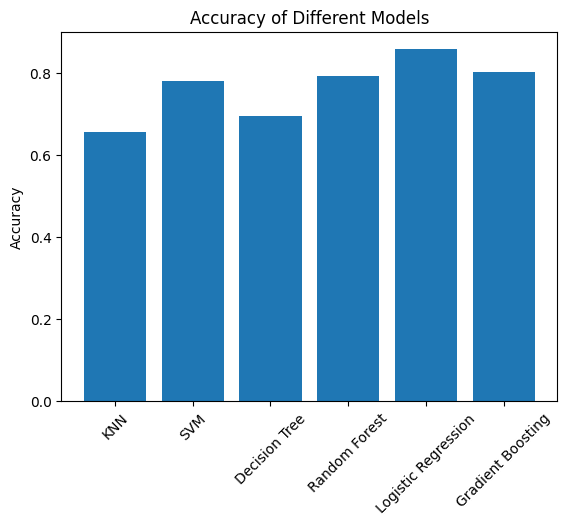

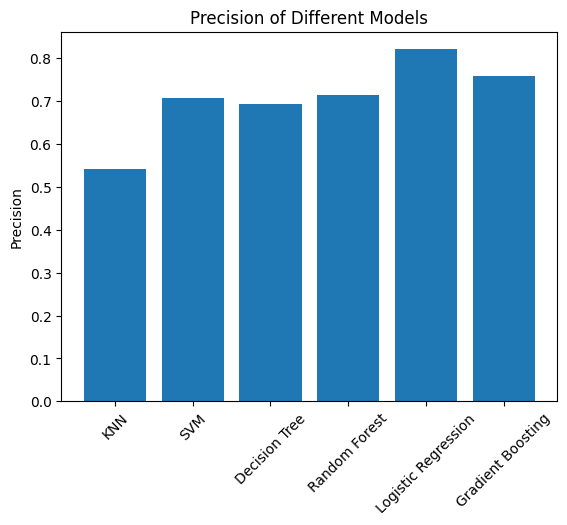

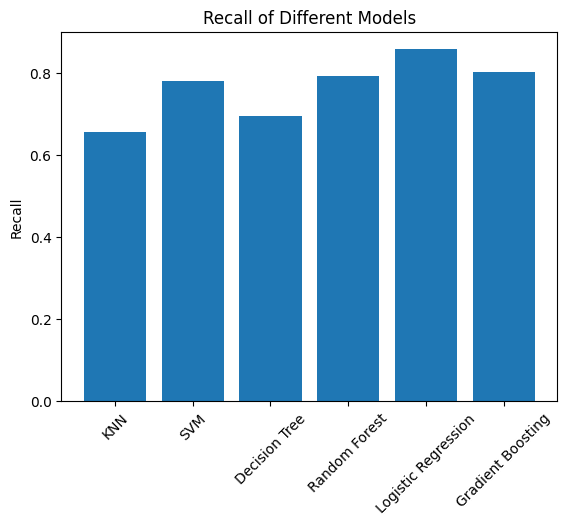

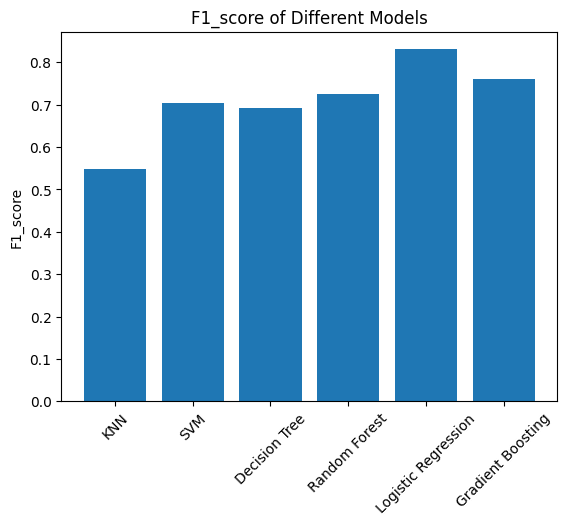

In [ ]:
def plot_results(results):
    metrics = ['accuracy', 'precision', 'recall', 'f1_score']
    for metric in metrics:
        plt.figure()
        plt.bar(results.keys(), [results[model][metric] for model in results])
        plt.title(f"{metric.capitalize()} of Different Models")
        plt.ylabel(metric.capitalize())
        plt.xticks(rotation=45)
        plt.show()

plot_results(results)


Explanation:

Visualizing results can provide intuitive insights into how each model performs across different metrics, aiding in understanding and presentation.


Step 10: Determine the Optimal Model

Finally, identify which model performed the best based on the F1 score:

In [ ]:
optimal_model = max(results.items(), key=lambda x: x[1]['f1_score'])
print(f"The optimal model is: {optimal_model[0]} with an F1 score of {optimal_model[1]['f1_score']:.2f}")


The optimal model is: Logistic Regression with an F1 score of 0.83


Explanation:

This segment finds the model with the highest F1 score, which balances precision and recall, providing a robust measure of performance in classification tasks.


Step 11: Model Evaluation

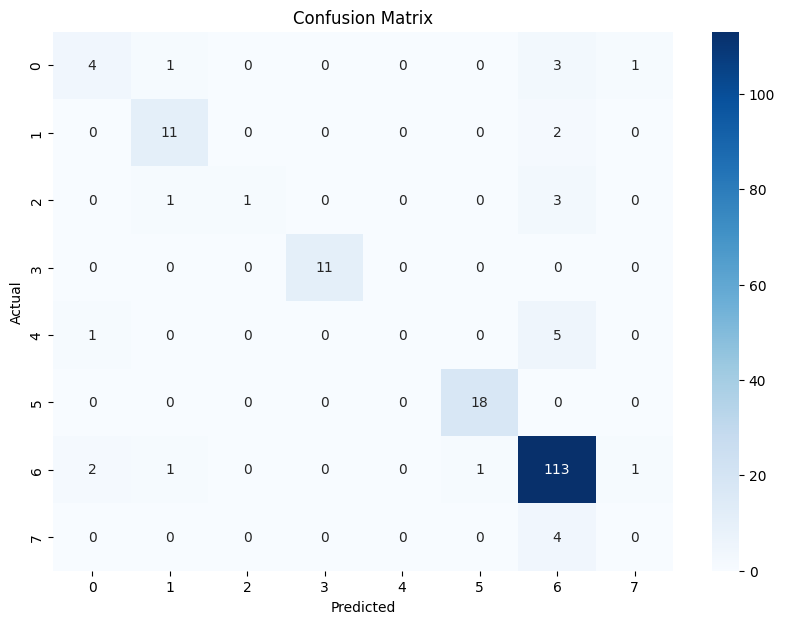

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.44      0.50         9
           1       0.79      0.85      0.81        13
           2       1.00      0.20      0.33         5
           3       1.00      1.00      1.00        11
           4       0.00      0.00      0.00         6
           5       0.95      1.00      0.97        18
           6       0.87      0.96      0.91       118
           7       0.00      0.00      0.00         4

    accuracy                           0.86       184
   macro avg       0.65      0.56      0.57       184
weighted avg       0.82      0.86      0.83       184



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load the dataset
csv_path = '/content/drive/MyDrive/MS THESIS_CSE_EWU/ckextended.csv'
data = pd.read_csv(csv_path)

# Step 2: Preprocess the images
def preprocess_images(data):
    images = []
    labels = []
    for index, row in data.iterrows():
        pixels = np.array(row['pixels'].split(), dtype=np.uint8)  # Convert string to array
        images.append(pixels.reshape(48, 48))  # Reshape to 48x48
        labels.append(row['emotion'])  # Assuming 'emotion' is the label
    return np.array(images), np.array(labels)

images, labels = preprocess_images(data)

# Flatten the images for Logistic Regression
processed_images = images.reshape(images.shape[0], -1)

# Step 3: Split the data
X_train, X_test, y_train, y_test = train_test_split(processed_images, labels, test_size=0.2, random_state=42)

# Step 4: Train Logistic Regression model
logistic_model = LogisticRegression(max_iter=200)
logistic_model.fit(X_train, y_train)

# Step 5: Make Predictions
y_pred = logistic_model.predict(X_test)

# Step 6: Evaluate the Model
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize Confusion Matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(labels), yticklabels=np.unique(labels))
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)


Analysis of the Classification Report
Overall Accuracy:
my model achieved an overall accuracy of 86%, which is quite good, especially for a multi-class classification problem.
Precision, Recall, and F1-Score:
Each class has different precision and recall values, indicating varied performance across different emotions:
Class 0 (Emotion 0): Precision = 0.57, Recall = 0.44, F1-score = 0.50. This class could use improvement.
Class 1 (Emotion 1): Good performance with high precision (0.79) and recall (0.85), resulting in an F1-score of 0.81.
Class 3 (Emotion 3): Perfect F1-score of 1.00, indicating the model predicts this emotion flawlessly.
Class 4 (Emotion 4): The model failed to classify any instances (all metrics are 0), suggesting a need for more data or better feature extraction for this class.
Class 6 (Emotion 6): Strong performance with a precision of 0.87 and recall of 0.96, resulting in an F1-score of 0.91.
Class 7 (Emotion 7): Again, the model struggled, as indicated by the 0 values.
Macro vs. Weighted Averages:
The macro average shows that the model performs decently but is affected by the low-performing classes.
The weighted average takes into account the number of instances in each class, providing a better picture of overall performance.

Step 12 : Visualizing Misclassifications

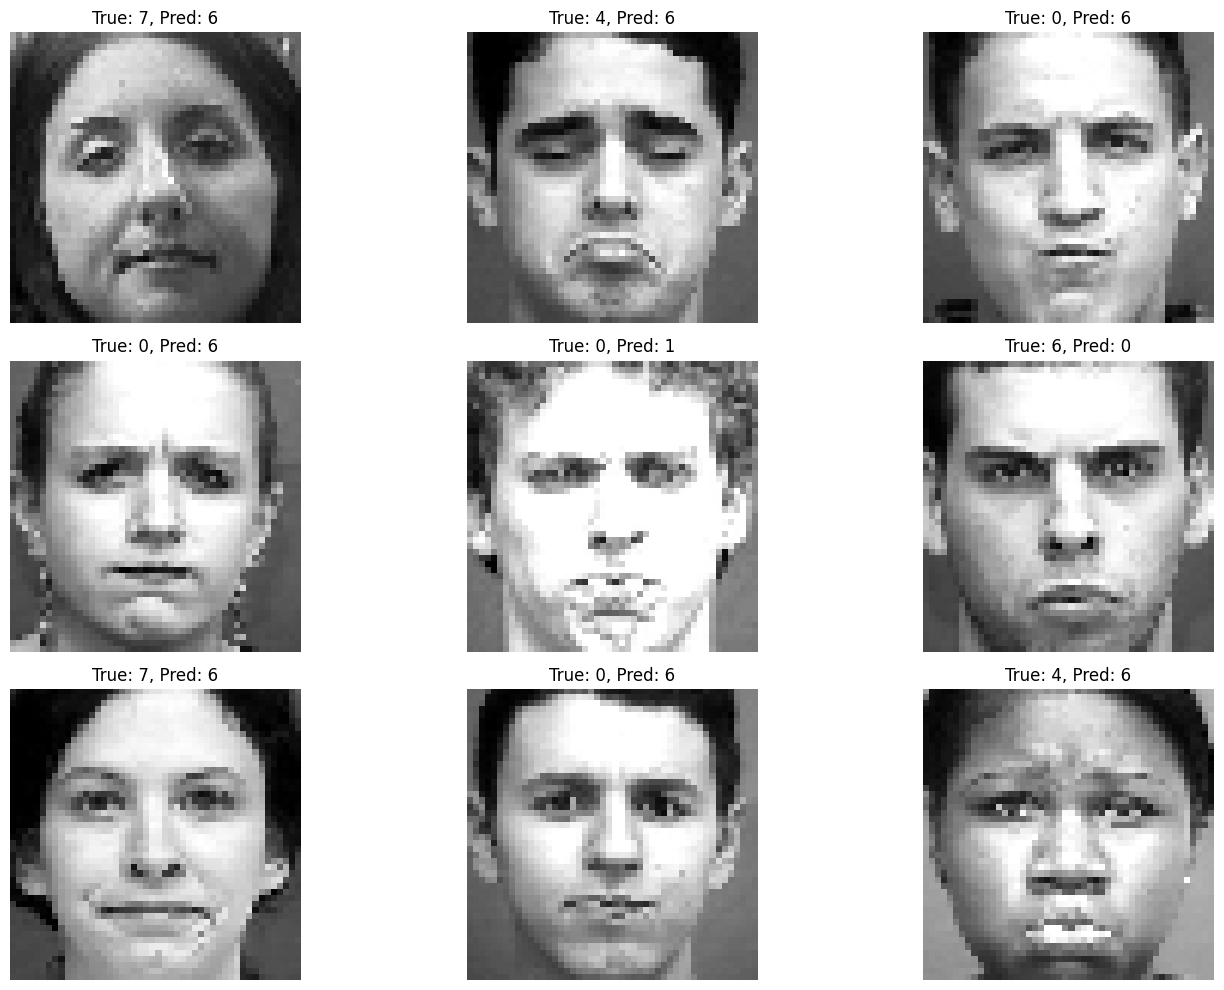

In [ ]:
# Identify misclassified samples
misclassified_indices = np.where(y_pred != y_test)[0]

# Visualize some misclassifications
plt.figure(figsize=(15, 10))
for i, idx in enumerate(misclassified_indices[:9]):  # Display first 9 misclassified images
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[idx].reshape(48, 48), cmap='gray')  # Reshape for visualization
    plt.title(f'True: {y_test[idx]}, Pred: {y_pred[idx]}')
    plt.axis('off')
plt.tight_layout()
plt.show()


Analysis of Misclassifications
Common Misclassifications:
For example, "True: 7, Pred: 6" means that when the true label was class 7 (emotion 7), the model predicted it as class 6 (emotion 6).
This is indicative of confusion between these two classes, which may occur if their features are similar in the dataset.
Understanding Misclassifications:
It can be helpful to examine which classes are frequently confused. This can provide insights into whether there are inherent similarities between those emotions or if the model struggles with specific classes due to lack of data.


Step 13 : Code to Analyze Misclassifications Further
Here’s how i can visualize more misclassified samples and also display the confusion matrix:

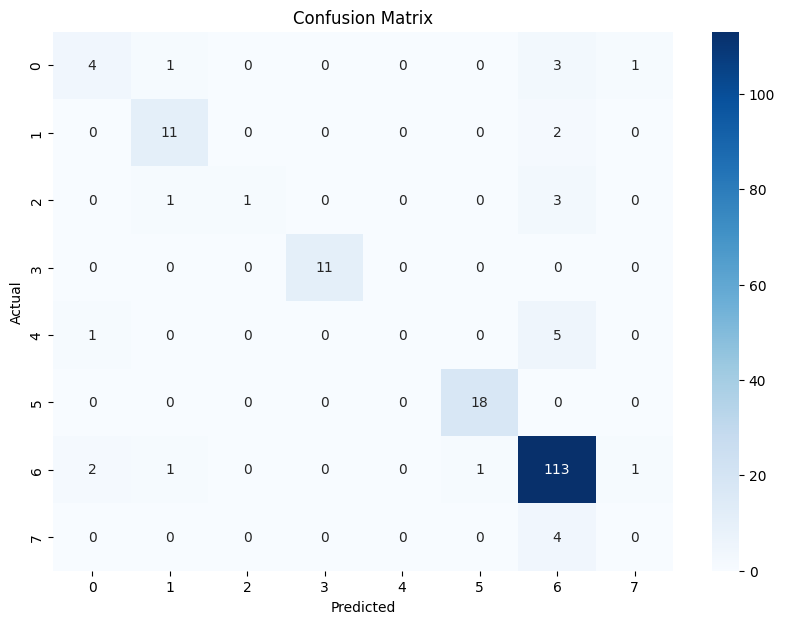

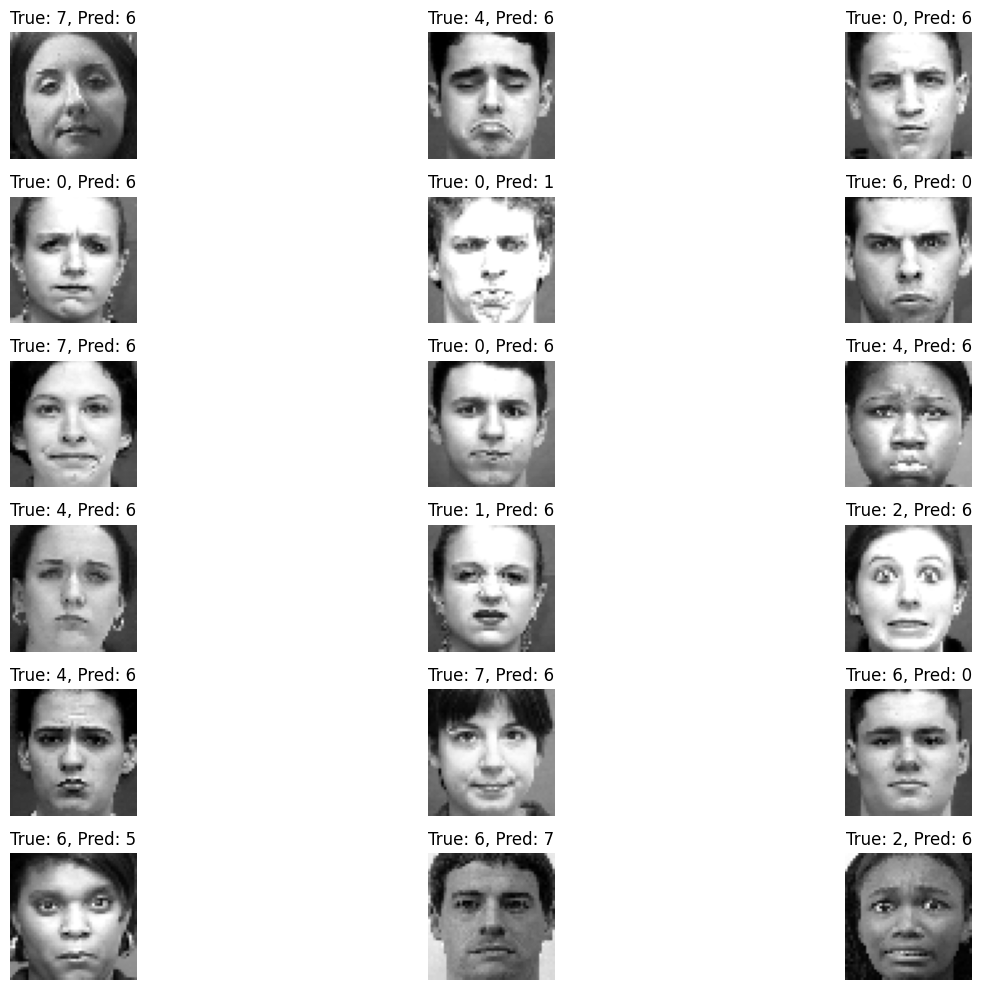

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize Confusion Matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# Identify misclassified samples
misclassified_indices = np.where(y_pred != y_test)[0]

# Visualize some misclassifications
plt.figure(figsize=(15, 10))
for i, idx in enumerate(misclassified_indices[:18]):  # Display first 18 misclassified images
    plt.subplot(6, 3, i + 1)
    plt.imshow(X_test[idx].reshape(48, 48), cmap='gray')  # Reshape for visualization
    plt.title(f'True: {y_test[idx]}, Pred: {y_pred[idx]}')
    plt.axis('off')
plt.tight_layout()
plt.show()


Summary
Analyzing the misclassifications will help me identify patterns in my model’s errors.
Visualizing a larger set of misclassified images can provide insight into why the model is struggling with certain emotions.
Consider applying the strategies discussed to enhance my model's performance.

Step 14: Confusion Matrix

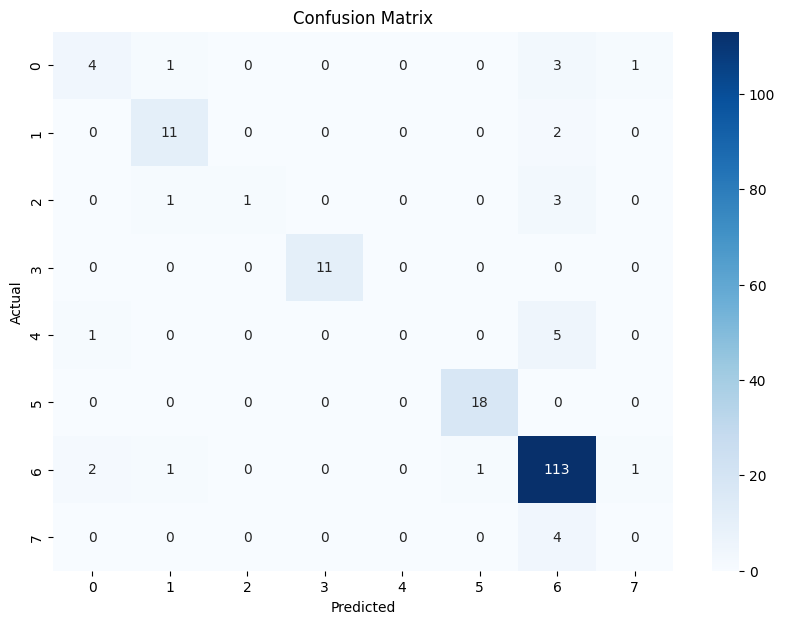

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize Confusion Matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()


Step 15: Visualize More Misclassifications

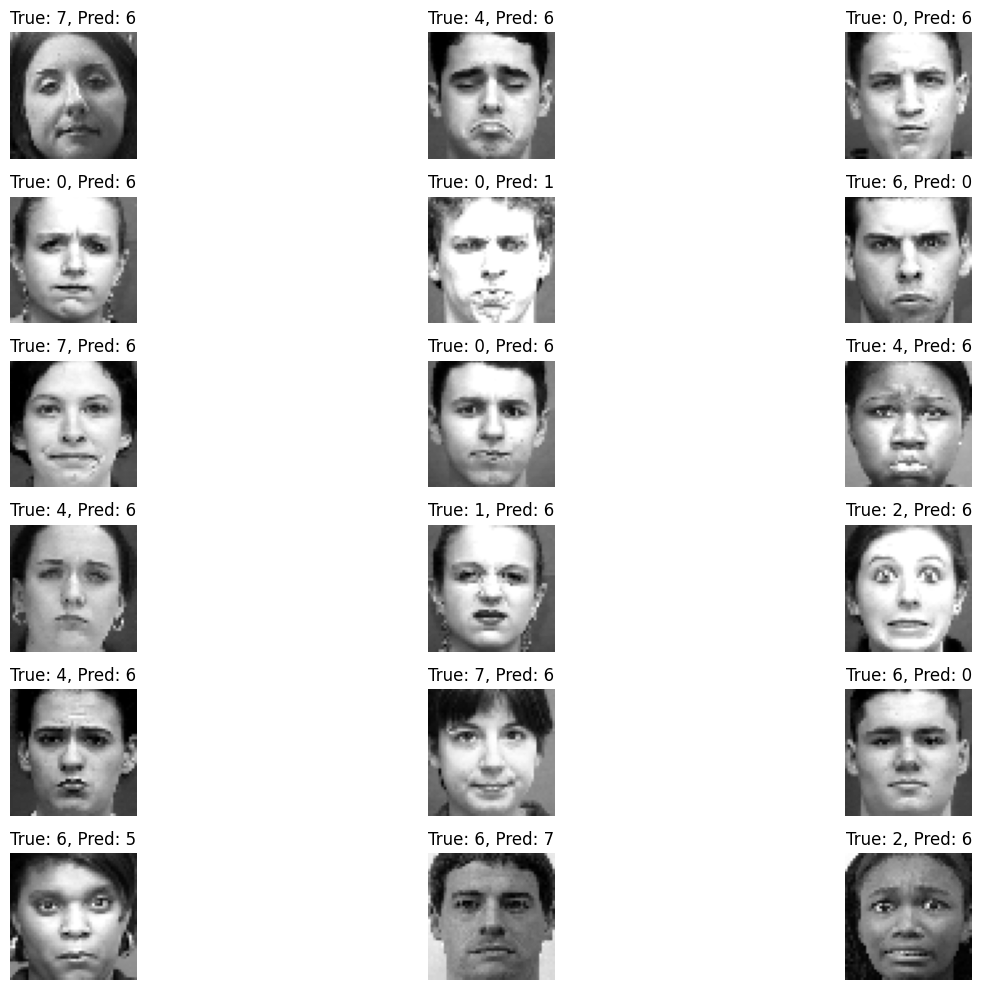

In [ ]:
# Identify misclassified samples
misclassified_indices = np.where(y_pred != y_test)[0]

# Visualize some misclassifications
plt.figure(figsize=(15, 10))
for i, idx in enumerate(misclassified_indices[:18]):  # Display first 18 misclassified images
    plt.subplot(6, 3, i + 1)
    plt.imshow(X_test[idx].reshape(48, 48), cmap='gray')  # Reshape for visualization
    plt.title(f'True: {y_test[idx]}, Pred: {y_pred[idx]}')
    plt.axis('off')
plt.tight_layout()
plt.show()


Step 16: Data Augmentation with OpenCV

In [ ]:
import cv2
import numpy as np

def augment_image(image):
    # Randomly apply transformations
    if np.random.rand() > 0.5:  # Random rotation
        angle = np.random.uniform(-20, 20)
        h, w = image.shape[:2]
        M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
        image = cv2.warpAffine(image, M, (w, h))

    if np.random.rand() > 0.5:  # Random width shift
        shift = np.random.randint(-5, 5)
        image = np.roll(image, shift, axis=1)

    if np.random.rand() > 0.5:  # Random height shift
        shift = np.random.randint(-5, 5)
        image = np.roll(image, shift, axis=0)

    return image

# Create augmented images for underrepresented classes
augmented_images = []
augmented_labels = []

underrepresented_classes = [4, 7]  # For example
for class_label in underrepresented_classes:
    class_indices = np.where(labels == class_label)[0]
    class_images = processed_images[class_indices]

    for img in class_images:
        for _ in range(10):  # Create 10 augmented images per original image
            augmented_img = augment_image(img.reshape(48, 48)).flatten()
            augmented_images.append(augmented_img)
            augmented_labels.append(class_label)

augmented_images = np.array(augmented_images)
augmented_labels = np.array(augmented_labels)

# Combine augmented data with original data
processed_images = np.concatenate((processed_images, augmented_images))
labels = np.concatenate((labels, augmented_labels))



STEP 17: Train Random Forest Model
After performing data augmentation, i can proceed with training the Random Forest model as shown previously:

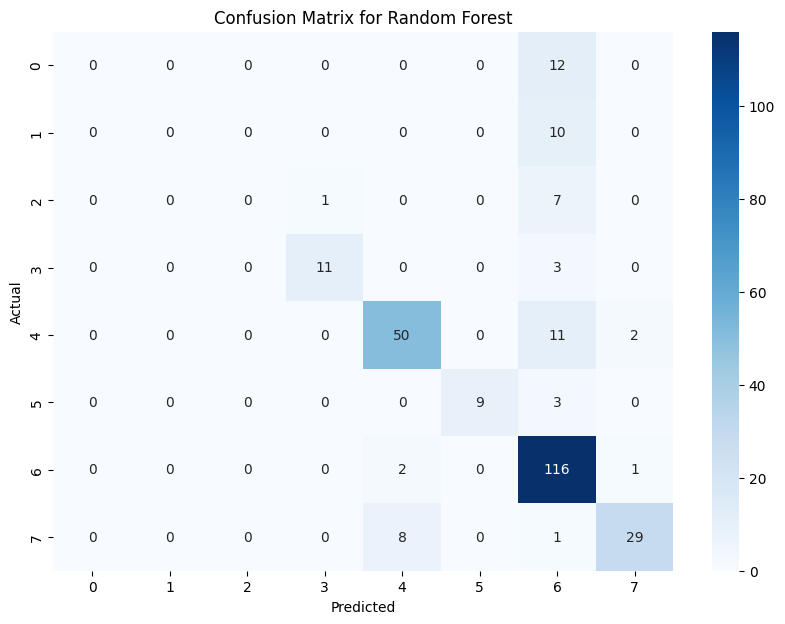

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.00      0.00      0.00        10
           2       0.00      0.00      0.00         8
           3       0.92      0.79      0.85        14
           4       0.83      0.79      0.81        63
           5       1.00      0.75      0.86        12
           6       0.71      0.97      0.82       119
           7       0.91      0.76      0.83        38

    accuracy                           0.78       276
   macro avg       0.55      0.51      0.52       276
weighted avg       0.71      0.78      0.73       276



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Split the data again after augmentation
X_train, X_test, y_train, y_test = train_test_split(processed_images, labels, test_size=0.2, random_state=42)

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make Predictions
rf_pred = rf_model.predict(X_test)

# Evaluate the Model
rf_cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(labels), yticklabels=np.unique(labels))
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix for Random Forest')
plt.show()

# Classification Report
rf_report = classification_report(y_test, rf_pred)
print("Classification Report for Random Forest:")
print(rf_report)


The classification report indicates that my Random Forest model is struggling with certain classes, leading to zero precision and recall for those labels. Here’s how to analyze and improve the situation:

Analysis of Results
Zero Precision and Recall:
The model is not predicting some classes at all (e.g., classes 0, 1, and 2), which results in zero precision and recall. This could mean:
These classes are underrepresented in the dataset.
The features of these classes are not distinct enough for the model to learn from them.
Class Imbalance:
It seems there’s a significant class imbalance. For example, class 6 has many samples, while classes 0, 1, and 2 have very few. This can lead to the model favoring the majority class.
Steps to Improve the Model
Analyze Class Distribution:
Check the distribution of classes to understand the extent of imbalance.
Data Augmentation:
Consider increasing the number of samples for the underrepresented classes more significantly.
Try Different Models:
Experiment with more complex models like Support Vector Machines or even neural networks, which might capture the underlying patterns better.
Adjust Class Weights:
Use class weights in the Random Forest model to give more importance to underrepresented classes.
Feature Engineering:
Explore additional features or different preprocessing techniques to help the model distinguish between classes.

STEP 18: Analyze Class Distribution

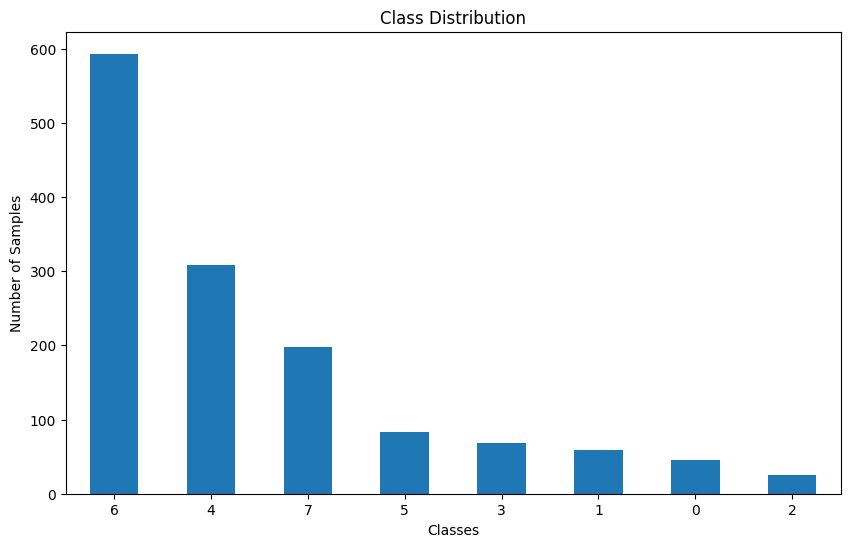

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Count the occurrences of each class
class_counts = pd.Series(labels).value_counts()

# Visualize the class distribution
plt.figure(figsize=(10, 6))
class_counts.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Classes')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.show()


STEP 19 : Adjusting the Augmentation Code

In [ ]:
# Initialize lists for augmented images and labels
augmented_images = []
augmented_labels = []

# Specify underrepresented classes
underrepresented_classes = [0, 1, 2]  # Classes that struggled previously

for class_label in underrepresented_classes:
    class_indices = np.where(labels == class_label)[0]
    class_images = processed_images[class_indices]

    for img in class_images:
        for _ in range(20):  # Increase the number of augmented images
            augmented_img = augment_image(img.reshape(48, 48)).flatten()
            augmented_images.append(augmented_img)  # Use append for lists
            augmented_labels.append(class_label)  # Use append for lists

# Convert lists to numpy arrays after augmentation
augmented_images = np.array(augmented_images)
augmented_labels = np.array(augmented_labels)

# Combine augmented data with original data again
processed_images = np.concatenate((processed_images, augmented_images))
labels = np.concatenate((labels, augmented_labels))


STEP 20 : Continue with Model Training
After this adjustment, you can proceed with training the Random Forest model as previously described:

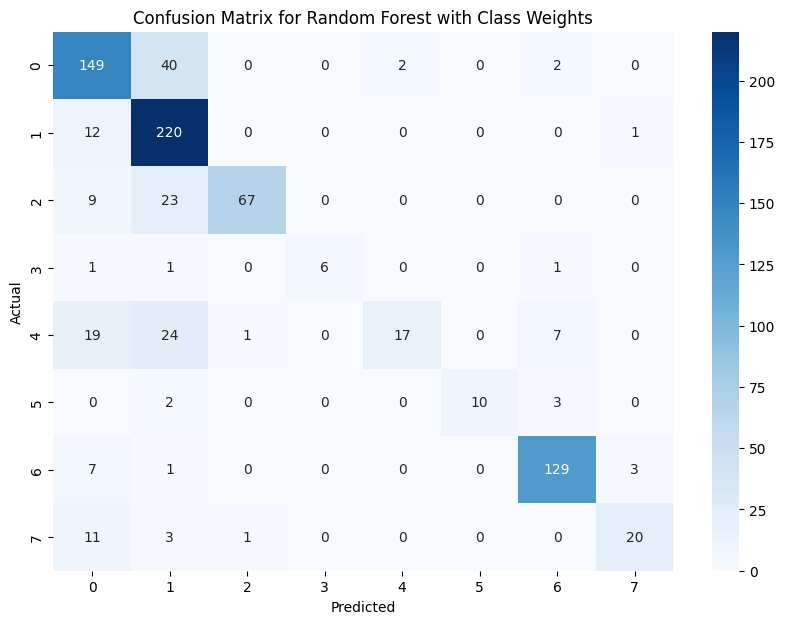

Classification Report for Random Forest with Class Weights:
              precision    recall  f1-score   support

           0       0.72      0.77      0.74       193
           1       0.70      0.94      0.80       233
           2       0.97      0.68      0.80        99
           3       1.00      0.67      0.80         9
           4       0.89      0.25      0.39        68
           5       1.00      0.67      0.80        15
           6       0.91      0.92      0.91       140
           7       0.83      0.57      0.68        35

    accuracy                           0.78       792
   macro avg       0.88      0.68      0.74       792
weighted avg       0.81      0.78      0.77       792



In [ ]:
from sklearn.utils import class_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Compute class weights
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(labels), y=labels)

# Split the data again after augmentation
X_train, X_test, y_train, y_test = train_test_split(processed_images, labels, test_size=0.2, random_state=42)

# Train Random Forest model with class weights
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight={i: weight for i, weight in enumerate(class_weights)})
rf_model.fit(X_train, y_train)

# Make Predictions
rf_pred = rf_model.predict(X_test)

# Evaluate the Model
rf_cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(labels), yticklabels=np.unique(labels))
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix for Random Forest with Class Weights')
plt.show()

# Classification Report
rf_report = classification_report(y_test, rf_pred)
print("Classification Report for Random Forest with Class Weights:")
print(rf_report)



Analysis of the Results
Precision and Recall:
Classes 0, 1, 2, and 6 are performing relatively well, with high precision and recall values.
Class 4 still struggles with low recall (0.25), indicating that many true instances of this class are not being correctly identified.
F1-Score:
The F1-score is a good balance between precision and recall. Classes 1, 2, and 6 have strong F1-scores, while class 4 remains a concern.
Support:
The support column shows how many instances of each class were present in the test set. Classes with fewer instances may inherently be more challenging to classify.


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Load the data
csv_path = '/content/drive/MyDrive/MS THESIS_CSE_EWU/ckextended.csv'
data = pd.read_csv(csv_path)

# Prepare images and labels
images = []  # Your image data here
labels = data['emotion'].values  # Your labels

# Preprocessing (flatten images if necessary)
processed_images = preprocess_images(images)  # Your preprocessing function

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(processed_images, labels, test_size=0.2, random_state=42, stratify=labels)



NameError: name 'preprocess_images' is not defined